# Indexing and searching image based documents (using ColPali with Qdrant)
We can retrieve documents with images such as user guides or old scanned documents. We will use an embedding model for the documents and the queries that supports images. We will also tune the vector database to efficiently store and search these embedding vectors.

Here are the steps:

- Creating image collection index
- Searching the image index
- Generating a reply based on the retrieved image

#### Visual Improvements

In [1]:
from rich.console import Console
from rich_theme_manager import Theme, ThemeManager
import pathlib

theme_dir = pathlib.Path("themes")
theme_manager = ThemeManager(theme_dir=theme_dir)
dark = theme_manager.get("dark")

# Create a console with the dark theme
console = Console(theme=dark)
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

## Creating image collection index
### Converting PDF files into images
We don't want to rely on text extraction from the PDF files, and we want to focus on the visual aspects of the pages.

In [2]:
import os
from pdf2image import convert_from_path


def convert_pdfs_to_images(pdf_folder):
    pdf_files = [f for f in os.listdir(pdf_folder) if f.endswith(".pdf")]
    all_images = {}

    for doc_id, pdf_file in enumerate(pdf_files):
        pdf_path = os.path.join(pdf_folder, pdf_file)
        images = convert_from_path(pdf_path, poppler_path="/usr/local/bin")
        all_images[pdf_file] = images

    return all_images
# all_images = convert_pdfs_to_images("data/ikea/")
all_images = convert_pdfs_to_images("data/shokz/")
console.print(all_images)

{
    'openrun_pro_user_guide.pdf': [
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x1114BF690>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x10CE634D0>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x111142410>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x10CEA6810>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x1114BEDD0>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x111FBBD90>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x111FBBE90>,
        <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=749x749 at 0x111FBBF90>
    ]
}

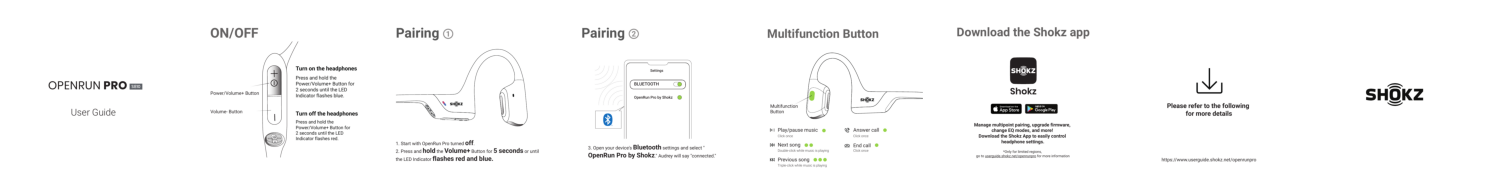

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(15, 10))

first_pdf_key = next(iter(all_images))
for i, ax in enumerate(axes.flat):
    img = all_images[first_pdf_key][i]
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [4]:
from colpali_engine.models import ColPali, ColPaliProcessor
import torch


# Initialize ColPali model and processor
model_name = (
    "vidore/colpali-v1.2"  # Use the latest version available
)
colpali_model = ColPali.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="cpu",  # Use "cuda:0" for GPU, "cpu" for CPU, or "mps" for Apple Silicon
)
colpali_processor = ColPaliProcessor.from_pretrained(
    "vidore/colpaligemma-3b-pt-448-base"
)

console.print(colpali_model)

`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of the model checkpoint at vidore/colpaligemma-3b-pt-448-base were not used when initializing ColPali: ['model.language_model.model.embed_tokens.weight', 'model.language_model.model.layers.0.input_layernorm.weight', 'model.language_model.model.layers.0.mlp.down_proj.weight', 'model.language_model.model.layers.0.mlp.gate_proj.weight', 'model.language_model.model.layers.0.mlp.up_proj.weight', 'model.language_model.model.layers.0.post_attention_layernorm.weight', 'model.language_model.model.layers.0.self_attn.k_proj.weight', 'model.language_model.model.layers.0.self_attn.o_proj.weight', 'model.language_model.model.layers.0.self_attn.q_proj.weight', 'model.language_model.model.layers.0.self_attn.v_proj.weight', 'model.language_model.model.layers.1.input_layernorm.weight', 'model.language_model.model.layers.1.mlp.down_proj.weight', 'model.language_model.model.layers.1.mlp.gate_proj.weight', 'model.language_model.model.layers.1.mlp.up_proj.weight', 'model.language_model.model.la

ColPali(
  (model): PaliGemmaForConditionalGeneration(
    (model): PaliGemmaModel(
      (vision_tower): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(1024, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
                )
                (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (mlp): SiglipMLP(
                  (activation_fn): GELUTanh()
                  (fc1): Linear(in_features=1152, out_features=4304, bias=True)
                  (fc2): Linear(in_features=4304, out_features=1152, bias=True)
                )
              )
            )
          )
          (post_layernorm): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
        )
      )
      (multi_modal_projector): PaliGemmaMultiModalProjector(
        (linear): Linear(in_features=1152, out_features=2048, bias=True)
      )
      (language_model): GemmaModel(
        (embed_tokens): Embedding(257216, 2048, padding_idx=0)
        (layers): ModuleList(
          (0-17): 18 x GemmaDecoderLayer(
            (self_attn): GemmaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=256, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (v_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=256, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=256, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (o_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
 

In [5]:
sample_image = all_images[first_pdf_key][0]
with torch.no_grad():
    sample_batch = colpali_processor.process_images([sample_image]).to(
        colpali_model.device
    )
    sample_embedding = colpali_model(**sample_batch)


console.print(sample_embedding)

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


tensor([[[-0.0618, -0.0164, -0.0723,  ..., -0.1138, -0.0957, -0.1406],
         [-0.0586, -0.0221, -0.0742,  ..., -0.1104, -0.0972, -0.1436],
         [-0.0625, -0.0165, -0.0640,  ..., -0.1108, -0.0938, -0.1436],
         ...,
         [-0.0280, -0.0728, -0.0201,  ..., -0.0439, -0.0620, -0.0393],
         [ 0.0030,  0.0864,  0.0422,  ..., -0.0386, -0.0258,  0.0698],
         [-0.1113, -0.0427, -0.0211,  ..., -0.1367, -0.0344, -0.1484]]],
       dtype=torch.bfloat16)

In [6]:
from rich.table import Table

table = Table(title="Document Embedding")
table.add_column("Documents", style="cyan", no_wrap=True)
table.add_column("Tokens", style="bright_yellow")
table.add_column("Vector Size", style="green")

table.add_row(
    str(sample_embedding.shape[0]), 
    str(sample_embedding.shape[1]), 
    str(sample_embedding.shape[2])
)

console.print(table)

         Document Embedding         
┏━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Documents ┃ Tokens ┃ Vector Size ┃
┡━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1         │ 1030   │ 128         │
└───────────┴────────┴─────────────┘

In [7]:
from qdrant_client import QdrantClient

qdrant_client = QdrantClient(
    ":memory:"
)  # Use ":memory:" for in-memory database or "path/to/db" for persistent storage
vector_size = sample_embedding.shape[2]

In [8]:
from qdrant_client.http import models

multi_vector_params = models.VectorParams(
    size=vector_size,
    distance=models.Distance.COSINE,
    multivector_config=models.MultiVectorConfig(
        comparator=models.MultiVectorComparator.MAX_SIM
    ),
)

### Reducing vector memory using Quantization
We can define a ScalarQuantizationConfig and pass it when creating the collection. On the server side, Qdrant will convert the vectors to 8-bit integers, reducing the memory footprint and speeding up the search process. You can also switch on or off the always_ram parameter, keeping the vectors in RAM. This will increase performance at the cost of memory usage.

In [9]:
scalar_quant = models.ScalarQuantizationConfig(
    type=models.ScalarType.INT8,
    quantile=0.99,
    always_ram=False,
)

In [10]:
collection_name="user-guides"

qdrant_client.recreate_collection(
    collection_name=collection_name,  # the name of the collection
    on_disk_payload=True,  # store the payload on disk
    optimizers_config=models.OptimizersConfigDiff(
        indexing_threshold=100
    ),  # it can be useful to swith this off when doing a bulk upload and then manually trigger the indexing once the upload is done
    vectors_config=models.VectorParams(
        size=vector_size,
        distance=models.Distance.COSINE,
        multivector_config=models.MultiVectorConfig(
            comparator=models.MultiVectorComparator.MAX_SIM
        ),
        quantization_config=models.ScalarQuantization(
            scalar=scalar_quant,
        ),
    ),
)

True

### Upserting the encoded images into the vector database
We define a helper function to upload points to Qdrant via the client. We use the stamina library to enable retries in case of network issues

In [11]:
import stamina

@stamina.retry(on=Exception, attempts=3)
def upsert_to_qdrant(batch):
    try:
        qdrant_client.upsert(
            collection_name=collection_name,
            points=points,
            wait=False,
        )
    except Exception as e:
        print(f"Error during upsert: {e}")
        return False
    return True

We will now upload the vectors to qdrant. We do this by creating batches of data, passing it through the ColPali model and then adding the embeddings to a Qdrant PointStruct.

In [12]:
import uuid
from tqdm import tqdm

batch_size = 2  # Adjust based on your GPU memory constraints

total_images = sum(len(images) for images in all_images.values())

# Use tqdm to create a progress bar
with tqdm(total=total_images, desc="Indexing Progress") as pbar:
    for doc_id, pdf_file in enumerate(all_images.keys()):
        for i in range(0, len(all_images[pdf_file]), batch_size):
            images = all_images[pdf_file][i : i + batch_size]

            # Process and encode images
            with torch.no_grad():
                batch_images = colpali_processor.process_images(images).to(
                    colpali_model.device
                )
                image_embeddings = colpali_model(**batch_images)

            # Prepare points for Qdrant
            points = []
            for j, embedding in enumerate(image_embeddings):
                unique_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{doc_id}.{i + j}"))
                # Convert the embedding to a list of vectors
                multivector = embedding.cpu().float().numpy().tolist()
                points.append(
                    models.PointStruct(
                        id=unique_id,  
                        vector=multivector,  # This is now a list of vectors
                        payload={
                            "doc": pdf_file, 
                            "page": i+j+1
                        },  # can also add other metadata/data
                    )
                )
            # Upload points to Qdrant
            try:
                upsert_to_qdrant(points)
            # clown level error handling here 🤡
            except Exception as e:
                print(f"Error during upsert: {e}")
                continue

            # Update the progress bar
            pbar.update(batch_size)

print("Indexing complete!")

Indexing Progress: 100%|██████████| 8/8 [2:46:58<00:00, 1252.30s/it]

Indexing complete!


If you had the indexing off during the upload you can trigger an index by setting a lower indexing threshold.

In [17]:
qdrant_client.update_collection(
    collection_name=collection_name,
    optimizers_config=models.OptimizersConfigDiff(indexing_threshold=10),
)

False

In [18]:
console.print( 
    qdrant_client
    .get_collection(collection_name)
)

CollectionInfo(
    status=<CollectionStatus.GREEN: 'green'>,
    optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>,
    warnings=None,
    indexed_vectors_count=0,
    points_count=8,
    segments_count=1,
    config=CollectionConfig(
        params=CollectionParams(
            vectors=VectorParams(
                size=128,
                distance=<Distance.COSINE: 'Cosine'>,
                hnsw_config=None,
                quantization_config=ScalarQuantization(
                    scalar=ScalarQuantizationConfig(
                        type=<ScalarType.INT8: 'int8'>,
                        quantile=0.99,
                        always_ram=False
                    )
                ),
                on_disk=None,
                datatype=None,
                multivector_config=MultiVectorConfig(comparator=<MultiVectorComparator.MAX_SIM: 'max_sim'>)
            ),
            shard_number=None,
            sharding_method=None,
            replication_factor=None,
            write_consistency_factor=None,
            read_fan_out_factor=None,
            read_fan_out_delay_ms=None,
            on_disk_payload=None,
            sparse_vectors=None
        ),
        hnsw_config=HnswConfig(
            m=16,
            ef_construct=100,
            full_scan_threshold=10000,
            max_indexing_threads=0,
            on_disk=None,
            payload_m=None,
            inline_storage=None
        ),
        optimizer_config=OptimizersConfig(
            deleted_threshold=0.2,
            vacuum_min_vector_number=1000,
            default_segment_number=0,
            max_segment_size=None,
            memmap_threshold=None,
            indexing_threshold=20000,
            flush_interval_sec=5,
            max_optimization_threads=1,
            prevent_unoptimized=None
        ),
        wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0, wal_retain_closed=1),
        quantization_config=None,
        strict_mode_config=None,
        metadata=None
    ),
    payload_schema={},
    update_queue=None
)

In [19]:
console.print(
    qdrant_client
    .scroll(
        collection_name=collection_name, 
        limit=20
    )
)

(
    [
        Record(
            id='2d51c088-46a9-509d-816e-cbf4b348233e',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 3},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='462685c4-e334-5911-908b-938cfad62d4b',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 4},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='59be58f4-0957-5621-bd37-2ac4f836f6b2',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 5},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='627cb812-738a-5e70-a04b-a53cb2fdf030',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 1},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='64b6d457-fe4f-5775-9e70-6120c9bc52e4',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 6},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='6da54e52-f04e-54a1-abbb-a548a77a0dea',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 2},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='9ff41a4f-5233-553f-b10a-4c1861a49989',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 8},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        Record(
            id='a6c1e115-7f15-5940-a876-19dbbf5a4d80',
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 7},
            vector=None,
            shard_key=None,
            order_value=None
        )
    ],
    None
)

## Searching the image index
Once we uploaded the encoded images to the vector database, we can query it.

In [20]:
# query_text = "How do I answer a call?"
query_text = "Why the led is flashing red and blue?"
with torch.no_grad():
    batch_query = colpali_processor.process_queries([query_text]).to(
        colpali_model.device
    )
    query_embedding = colpali_model(**batch_query)
console.print(query_embedding.shape)

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


torch.Size([1, 23, 128])

In [21]:
# Convert the query embedding to a list of vectors
multivector_query = query_embedding[0].cpu().float().numpy().tolist()
search_result = qdrant_client.query_points(
    collection_name=collection_name, 
    query=multivector_query, 
    limit=3, 
    timeout=60,
)
console.print(search_result)

QueryResponse(
    points=[
        ScoredPoint(
            id='627cb812-738a-5e70-a04b-a53cb2fdf030',
            version=0,
            score=3.1460098164043617,
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 1},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        ScoredPoint(
            id='59be58f4-0957-5621-bd37-2ac4f836f6b2',
            version=0,
            score=3.1297680740733593,
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 5},
            vector=None,
            shard_key=None,
            order_value=None
        ),
        ScoredPoint(
            id='6da54e52-f04e-54a1-abbb-a548a77a0dea',
            version=0,
            score=3.115474875380911,
            payload={'doc': 'openrun_pro_user_guide.pdf', 'page': 2},
            vector=None,
            shard_key=None,
            order_value=None
        )
    ]
)

### Show the search results images
We can display the images that were retrieved by the vector search.



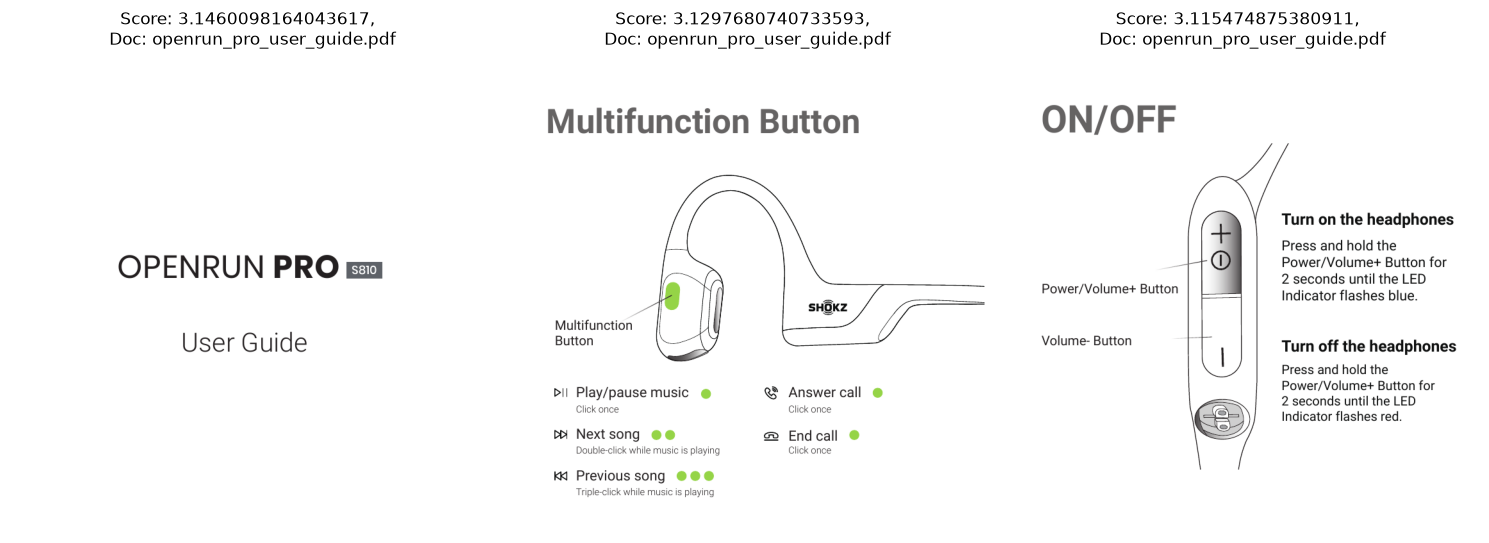

In [22]:
import matplotlib.pyplot as plt

# Extract the top 3 images from the search result for display
top_images = search_result.points[:6]

# Create a figure with subplots for each image
fig, axs = plt.subplots(1, 3, figsize=(15, 10))

# Iterate over the top images and plot each one
for i, point in enumerate(top_images):
    pdf_file = point.payload.get('doc')
    page_num = int(point.payload.get('page')) - 1
    img = all_images[pdf_file][page_num]
    axs[i].imshow(img)
    axs[i].set_title(f"Score: {point.score}, \n Doc: {pdf_file}")
    axs[i].axis('off')  # Do not display axes for better visualization

plt.tight_layout()
plt.show()

## Generate response with the retrieved image(s)
In the Augmentation step we encode the retrieved image using base64 and send it as part of the prompt to the generation model, alongside the user's query.

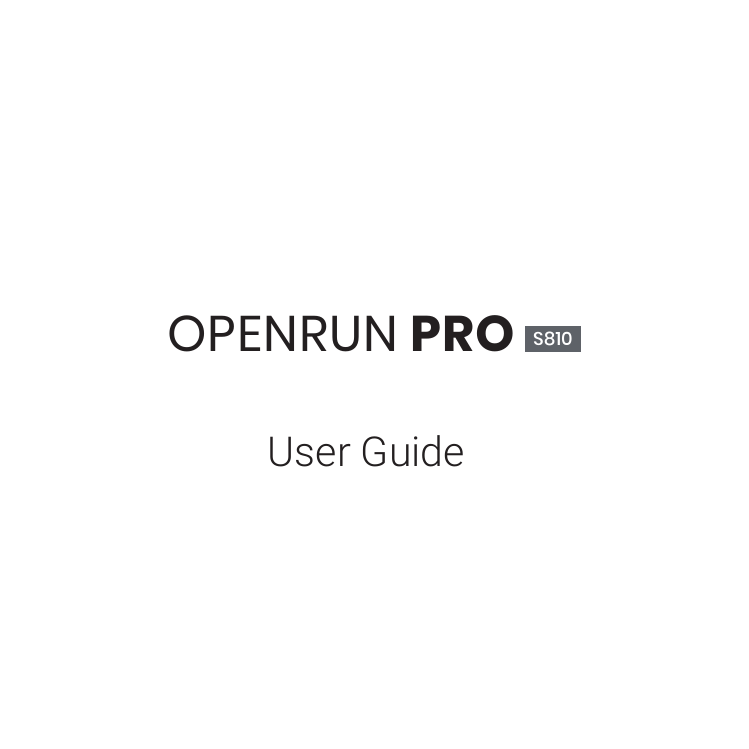

In [23]:
import base64
from io import BytesIO

top_image = search_result.points[0]
pdf_file = top_image.payload.get('doc')
page_num = int(top_image.payload.get('page')) - 1
image = all_images[pdf_file][page_num]
display(image)

buffered = BytesIO()
image.save(buffered, format="PNG")  # You may choose another format if needed
img_bytes = buffered.getvalue()

image1_media_type = "image/png"

image1_data = base64.standard_b64encode(img_bytes).decode("utf-8")

In [24]:
from dotenv import load_dotenv

load_dotenv()

True

In [25]:
from openai import OpenAI

client = OpenAI()
message = client.chat.completions.create(
    model="gpt-4o",
    max_tokens=1024,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:{image1_media_type};base64,{image1_data}"
                    },
                },
                {
                    "type": "text",
                    "text": query_text
                }
            ],
        }
    ],
)
console.print(message)


ChatCompletion(
    id='chatcmpl-E4O4BvhcY7MDRXDbhyasLbHtJQ0LG',
    choices=[
        Choice(
            finish_reason='stop',
            index=0,
            logprobs=None,
            message=ChatCompletionMessage(
                content="A flashing red and blue LED on your OpenRun Pro typically indicates that the device is in 
pairing mode. This means it's ready to connect to a Bluetooth device. To pair, make sure your Bluetooth is enabled 
on your device, and look for the OpenRun Pro in the list of available devices to connect. If this isn't the issue, 
check your user guide for further troubleshooting steps.",
                refusal=None,
                role='assistant',
                annotations=[],
                audio=None,
                function_call=None,
                tool_calls=None
            )
        )
    ],
    created=1784714531,
    model='gpt-4o-2024-08-06',
    object='chat.completion',
    moderation=None,
    service_tier='default',
    system_fingerprint='fp_6cd46c5087',
    usage=CompletionUsage(
        completion_tokens=76,
        prompt_tokens=781,
        total_tokens=857,
        completion_tokens_details=CompletionTokensDetails(
            accepted_prediction_tokens=0,
            audio_tokens=0,
            reasoning_tokens=0,
            rejected_prediction_tokens=0
        ),
        prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)
    )
)